# 💳 Credit Risk Prediction using Machine Learning

## Predição de Inadimplência em Crédito

### Projeto de Ciência de Dados End-to-End

---

## 🎯 Objetivo

Desenvolver um modelo de Machine Learning capaz de prever o risco de inadimplência em operações de crédito, auxiliando instituições financeiras na tomada de decisão.

O modelo busca identificar clientes com maior probabilidade de atraso no pagamento, permitindo uma análise de risco mais eficiente.

---

## 🏦 Problema de Negócio

A instituição financeira apresenta uma taxa de inadimplência aproximada de **35%** em sua carteira de crédito.

O objetivo do projeto é desenvolver uma solução preditiva capaz de auxiliar na redução desse índice para aproximadamente **25%**, utilizando técnicas de Machine Learning e análise de dados.

---

## 📂 Dados Utilizados

A base contém informações relacionadas ao perfil financeiro dos clientes, incluindo:

- Duração do crédito;
- Valor solicitado;
- Histórico de crédito;
- Propósito do empréstimo;
- Emprego;
- Profissão;
- Investimentos;
- Idade;
- Status de pagamento.

A variável alvo do modelo é:

**Status**
- 0 → Cliente inadimplente
- 1 → Cliente adimplente

---

## 🛠️ Tecnologias

- Python
- Pandas
- NumPy
- Matplotlib
- Scikit-Learn
- XGBoost
- SHAP
- PostgreSQL
- Tableau

---

## 🤖 Modelos Avaliados

Foram testados diferentes algoritmos de classificação:

- Logistic Regression
- Random Forest
- XGBoost

A escolha do modelo final considera métricas importantes para problemas de risco de crédito:

- Precision
- Recall
- F1-score
- ROC-AUC
- Matriz de Confusão

## Carregamento dos dados

In [1]:
from sqlalchemy import create_engine
import pandas as pd

usuario = "..."
senha = "..."
host = "localhost"
porta = "..."
banco = "credito"

engine = create_engine(
    f"postgresql://{usuario}:{senha}@{host}:{porta}/{banco}"
)

df = pd.read_sql(
    'SELECT * FROM "CREDITO"',
    engine
)

print(df.head())

ValueError: invalid literal for int() with base 10: '...'

In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   IDCREDITO             1000 non-null   int64  
 1   Duracao               1000 non-null   int64  
 2   HistoricoCredito      1000 non-null   int64  
 3   Proposito             1000 non-null   int64  
 4   Valor                 1000 non-null   int64  
 5   Investimentos         1000 non-null   int64  
 6   Emprego               1000 non-null   int64  
 7   TempoParcelamento     1000 non-null   int64  
 8   EstadoCivil           1000 non-null   int64  
 9   FiadorTerceiros       1000 non-null   int64  
 10  ResidenciaDesde       993 non-null    float64
 11  Idade                 1000 non-null   int64  
 12  OutrosFinanciamentos  1000 non-null   int64  
 13  Habitacao             1000 non-null   int64  
 14  EmprestimoExistente   1000 non-null   int64  
 15  Profissao             1000 non-nu

In [ ]:
df['ResidenciaDesde'].isnull().sum()

np.int64(7)

In [ ]:
df['ResidenciaDesde'] = df['ResidenciaDesde'].fillna(5)

In [ ]:
df.isnull().sum()

IDCREDITO               0
Duracao                 0
HistoricoCredito        0
Proposito               0
Valor                   0
Investimentos           0
Emprego                 0
TempoParcelamento       0
EstadoCivil             0
FiadorTerceiros         0
ResidenciaDesde         0
Idade                   0
OutrosFinanciamentos    0
Habitacao               0
EmprestimoExistente     0
Profissao               0
Dependentes             0
SocioEmpresa            0
Estrangeiro             0
Status                  0
dtype: int64

In [ ]:
df['ResidenciaDesde'].value_counts()

ResidenciaDesde
4.0    409
2.0    308
3.0    147
1.0    129
5.0      7
Name: count, dtype: int64

# SEPARANDO TREINO E TESTE

In [ ]:
X = df.drop(['IDCREDITO', 'Status'], axis=1)
y = df['Status']

In [ ]:
X.columns

Index(['Duracao', 'HistoricoCredito', 'Proposito', 'Valor', 'Investimentos',
       'Emprego', 'TempoParcelamento', 'EstadoCivil', 'FiadorTerceiros',
       'ResidenciaDesde', 'Idade', 'OutrosFinanciamentos', 'Habitacao',
       'EmprestimoExistente', 'Profissao', 'Dependentes', 'SocioEmpresa',
       'Estrangeiro'],
      dtype='str')

In [ ]:
y.value_counts()

Status
1    700
0    300
Name: count, dtype: int64

# SEPARANDO VALORES NUMERICOS DOS CATEGORICOS

In [ ]:
# VARIAVEIS NUMERICAS
numericas = [
    "Duracao", 
    "Valor",
    "Idade",
    "TempoParcelamento",
    "Dependentes"
]

In [ ]:
# VARIAVEIS CATEGORICAS
categoricas = [
    "HistoricoCredito",
    "Proposito",
    "Investimentos",
    "Emprego",
    "EstadoCivil",
    "FiadorTerceiros",
    "ResidenciaDesde",
    "OutrosFinanciamentos",
    "Habitacao",
    "EmprestimoExistente",
    "Profissao",
    "SocioEmpresa",
    "Estrangeiro"
]

In [ ]:
X.dtypes

Duracao                   int64
HistoricoCredito          int64
Proposito                 int64
Valor                     int64
Investimentos             int64
Emprego                   int64
TempoParcelamento         int64
EstadoCivil               int64
FiadorTerceiros           int64
ResidenciaDesde         float64
Idade                     int64
OutrosFinanciamentos      int64
Habitacao                 int64
EmprestimoExistente       int64
Profissao                 int64
Dependentes               int64
SocioEmpresa              int64
Estrangeiro               int64
dtype: object

In [ ]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(700, 18)
(300, 18)


# IMPORTAÇÃO DAS BIBLIOTECAS

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# TRATANDO OS VALORES NUMERICOS E CATEGORICOS

In [ ]:
# TRATAMENTO DAS VARIAVEIS NUMERICAS
pipeline_numerica = Pipeline([
    ('scaler', StandardScaler())
])

In [ ]:
# TRATAMENTO DAS VARIAVEIS CATEGORICAS
pipeline_categorica = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# TRANSFORMANDO AS VARIAVEIS COM OHE

In [ ]:
#TRANSFORMADOR
preprocessor = ColumnTransformer(
    transformers= [
        ("numericas", pipeline_numerica, numericas),
        ("categoricas", pipeline_categorica, categoricas)
    ]

)

# TREINAMENTO DO MODELO

In [ ]:
X_train_transformado = preprocessor.fit_transform(X_train)
X_test_transformado = preprocessor.transform(X_test)

In [ ]:
print(X.columns.tolist())

['Duracao', 'HistoricoCredito', 'Proposito', 'Valor', 'Investimentos', 'Emprego', 'TempoParcelamento', 'EstadoCivil', 'FiadorTerceiros', 'ResidenciaDesde', 'Idade', 'OutrosFinanciamentos', 'Habitacao', 'EmprestimoExistente', 'Profissao', 'Dependentes', 'SocioEmpresa', 'Estrangeiro']


In [ ]:
X_train_transformado.shape

(700, 65)

In [ ]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(700, 18)
(300, 18)
(700,)
(300,)


# CRIANDO O PRIMEIRO MODELO

In [ ]:
from sklearn.linear_model import LogisticRegression

modelolr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelolr.fit(X_train_transformado, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [ ]:
y_pred = modelolr.predict(X_test_transformado)

# AVALIACAO DO MODELO LOGISTICO

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

print("Acuracia:", accuracy_score(y_test, y_pred))

print(classification_report(y_test, y_pred))

Acuracia: 0.74
              precision    recall  f1-score   support

           0       0.60      0.40      0.48        90
           1       0.78      0.89      0.83       210

    accuracy                           0.74       300
   macro avg       0.69      0.64      0.65       300
weighted avg       0.72      0.74      0.72       300



# MATRIX DE CONFUSAO

In [ ]:
from sklearn.metrics import confusion_matrix

print("Matriz de Confusão:")
print(confusion_matrix(y_test, y_pred))

Matriz de Confusão:
[[ 36  54]
 [ 24 186]]


# CRIANDO O SEGUNDO MODELO REGRESSAO LOGISTICA NORMAL COM CLASS BALANCEADA

In [ ]:
modelo_lr_bal = LogisticRegression(
    max_iter=1000,
    random_state=42,
    class_weight="balanced"
)

modelo_lr_bal.fit(
    X_train_transformado,
    y_train
)

,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default 

In [ ]:
y_pred_bal = modelo_lr_bal.predict(X_test_transformado)

# AVALIANDO O RESULTADO

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test, y_pred_bal))

print(confusion_matrix(y_test, y_pred_bal))

              precision    recall  f1-score   support

           0       0.49      0.69      0.57        90
           1       0.84      0.69      0.76       210

    accuracy                           0.69       300
   macro avg       0.66      0.69      0.66       300
weighted avg       0.73      0.69      0.70       300

[[ 62  28]
 [ 65 145]]


In [ ]:
probabilidades = modelolr.predict_proba(X_test_transformado)

In [ ]:
probabilidades[:5]

array([[0.09664373, 0.90335627],
       [0.50347106, 0.49652894],
       [0.46415121, 0.53584879],
       [0.27119911, 0.72880089],
       [0.09566001, 0.90433999]])

# AJUSTANDO THRESHOLD

In [ ]:
from sklearn.metrics import confusion_matrix

prob_bom = modelo_lr_bal.predict_proba(X_test_transformado)[:,1]

for limite in [0.5, 0.6, 0.7, 0.8]:
    
    pred = (prob_bom >= limite).astype(int)
    
    cm = confusion_matrix(y_test, pred)
    
    print("Threshold:", limite)
    print(cm)
    print()

Threshold: 0.5
[[ 62  28]
 [ 65 145]]

Threshold: 0.6
[[ 75  15]
 [ 92 118]]

Threshold: 0.7
[[ 81   9]
 [132  78]]

Threshold: 0.8
[[ 86   4]
 [162  48]]



# MODELO XGBOOST


In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    scale_pos_weight=2.33,
    eval_metric='logloss'
)

In [ ]:
xgb.fit(X_train_transformado, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
y_pred_xgb = xgb.predict(X_test_transformado)

# AVALIANDO O XGB COM PESOS

In [ ]:
print('ACURACIA:', accuracy_score(y_test, y_pred_xgb))

print(classification_report(y_test, y_pred_xgb))

print(confusion_matrix(y_test, y_pred_xgb))

ACURACIA: 0.7533333333333333
              precision    recall  f1-score   support

           0       0.66      0.37      0.47        90
           1       0.77      0.92      0.84       210

    accuracy                           0.75       300
   macro avg       0.72      0.64      0.66       300
weighted avg       0.74      0.75      0.73       300

[[ 33  57]
 [ 17 193]]


In [ ]:
prob_xgb = xgb.predict_proba(X_test_transformado)[:,1]

# AJUSTANDO O THRESHOLD COM PESOS

In [ ]:
from sklearn.metrics import confusion_matrix

for limite in [0.5,0.6,0.7,0.8]:
    
    pred = (prob_xgb >= limite).astype(int)

    print("Threshold:", limite)
    print(confusion_matrix(y_test, pred))
    print()

Threshold: 0.5
[[ 33  57]
 [ 17 193]]

Threshold: 0.6
[[ 41  49]
 [ 21 189]]

Threshold: 0.7
[[ 48  42]
 [ 41 169]]

Threshold: 0.8
[[ 55  35]
 [ 60 150]]



# MODELO XGBOOST SEM PESOS

In [ ]:
from xgboost import XGBClassifier

modelo_xgb_normal = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
modelo_xgb_normal.fit(
    X_train_transformado,
    y_train
)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [ ]:
y_pred_xgb_normal = modelo_xgb_normal.predict(
    X_test_transformado
)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Acurácia:", accuracy_score(y_test, y_pred_xgb_normal))

print(classification_report(y_test, y_pred_xgb_normal))

print(confusion_matrix(y_test, y_pred_xgb_normal))

Acurácia: 0.77
              precision    recall  f1-score   support

           0       0.70      0.41      0.52        90
           1       0.79      0.92      0.85       210

    accuracy                           0.77       300
   macro avg       0.74      0.67      0.68       300
weighted avg       0.76      0.77      0.75       300

[[ 37  53]
 [ 16 194]]


# THRESHOLD XGB SEM PESO

In [ ]:
prob_xgb_normal = modelo_xgb_normal.predict_proba(
    X_test_transformado
)[:,1]

In [ ]:
from sklearn.metrics import confusion_matrix

for limite in [0.5, 0.6, 0.7, 0.8]:
    
    pred = (prob_xgb_normal >= limite).astype(int)

    print("Threshold:", limite)
    print(confusion_matrix(y_test, pred))
    print()

Threshold: 0.5
[[ 37  53]
 [ 16 194]]

Threshold: 0.6
[[ 53  37]
 [ 38 172]]

Threshold: 0.7
[[ 71  19]
 [ 71 139]]

Threshold: 0.8
[[ 79  11]
 [115  95]]



# VALIDACAO CRUZADA ESTRATIFICADA (5 FOLDS)


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [ ]:
from sklearn.pipeline import Pipeline

pipeline_xgb = Pipeline([
    ("preprocessamento", preprocessor),
    ("modelo", XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    ))
])

In [ ]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [ ]:
metricas = [
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc"
]

In [ ]:
resultado = cross_validate(
    pipeline_xgb,
    X,
    y,
    cv=cv,
    scoring=metricas,
    return_train_score=False
)

In [ ]:
for metrica in metricas:
    print(
        f"{metrica}: "
        f"{resultado['test_' + metrica].mean():.4f} "
        f"(± {resultado['test_' + metrica].std():.4f})"
    )

accuracy: 0.7270 (± 0.0133)
precision: 0.7613 (± 0.0155)
recall: 0.8900 (± 0.0273)
f1: 0.8202 (± 0.0092)
roc_auc: 0.7402 (± 0.0183)


# EXPLICABILIDADE (SHAP)

In [ ]:
import shap

explainer = shap.TreeExplainer(modelo_xgb_normal)

shap_values = explainer.shap_values(X_test_transformado)

c:\Users\nimgu\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# CRIANDO O GRAFICO PARA VISUALIZAR AS PRINCIPAIS TABELAS QUE INFLUÊNCIAM NO CRÉDITO

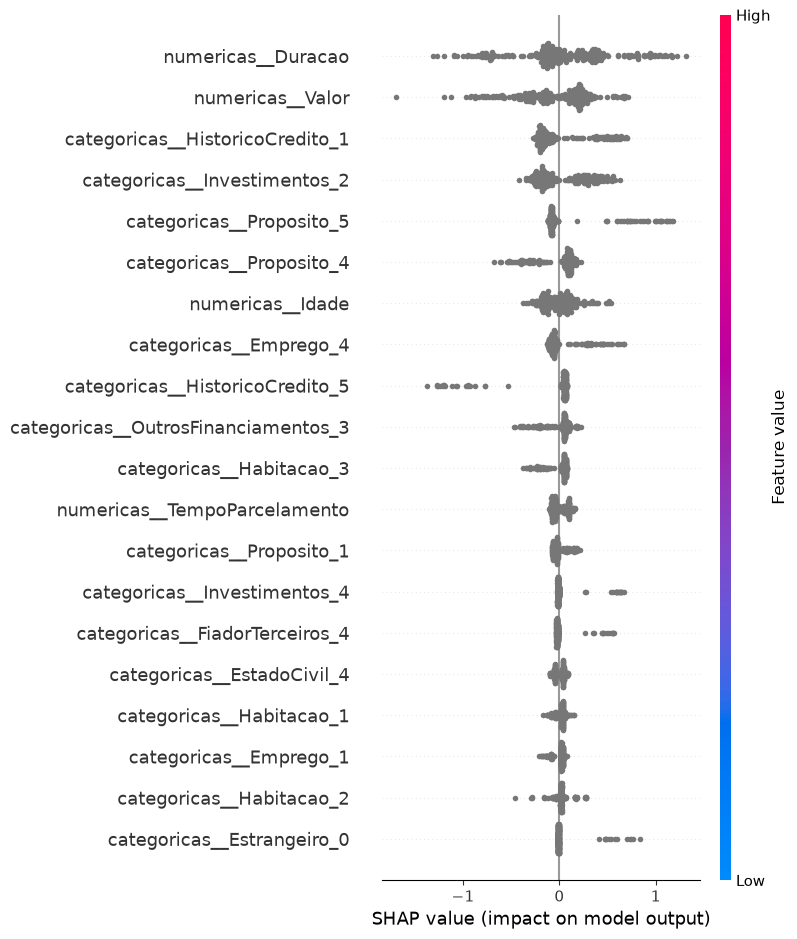

In [ ]:
feature_names = preprocessor.get_feature_names_out()

shap.summary_plot(
    shap_values,
    X_test_transformado,
    feature_names=feature_names
)

# IMPORTANCIA DAS VARIAVEIS COM SHAP

In [ ]:
# CRIANDO O EXPLICADOR
explainer = shap.TreeExplainer(modelo_xgb_normal)

In [ ]:
# Calcular os valores SHAP
shap_values = explainer.shap_values(X_test_transformado)

In [ ]:
# Obter os nomes das features após o pré-processamento
feature_names = preprocessor.get_feature_names_out()

In [ ]:
# Gerar a importância das variáveis com SHAP
print(feature_names[:20])

['numericas__Duracao' 'numericas__Valor' 'numericas__Idade'
 'numericas__TempoParcelamento' 'numericas__Dependentes'
 'categoricas__HistoricoCredito_0' 'categoricas__HistoricoCredito_1'
 'categoricas__HistoricoCredito_2' 'categoricas__HistoricoCredito_3'
 'categoricas__HistoricoCredito_4' 'categoricas__HistoricoCredito_5'
 'categoricas__Proposito_1' 'categoricas__Proposito_2'
 'categoricas__Proposito_3' 'categoricas__Proposito_4'
 'categoricas__Proposito_5' 'categoricas__Proposito_6'
 'categoricas__Proposito_7' 'categoricas__Proposito_8'
 'categoricas__Proposito_9']


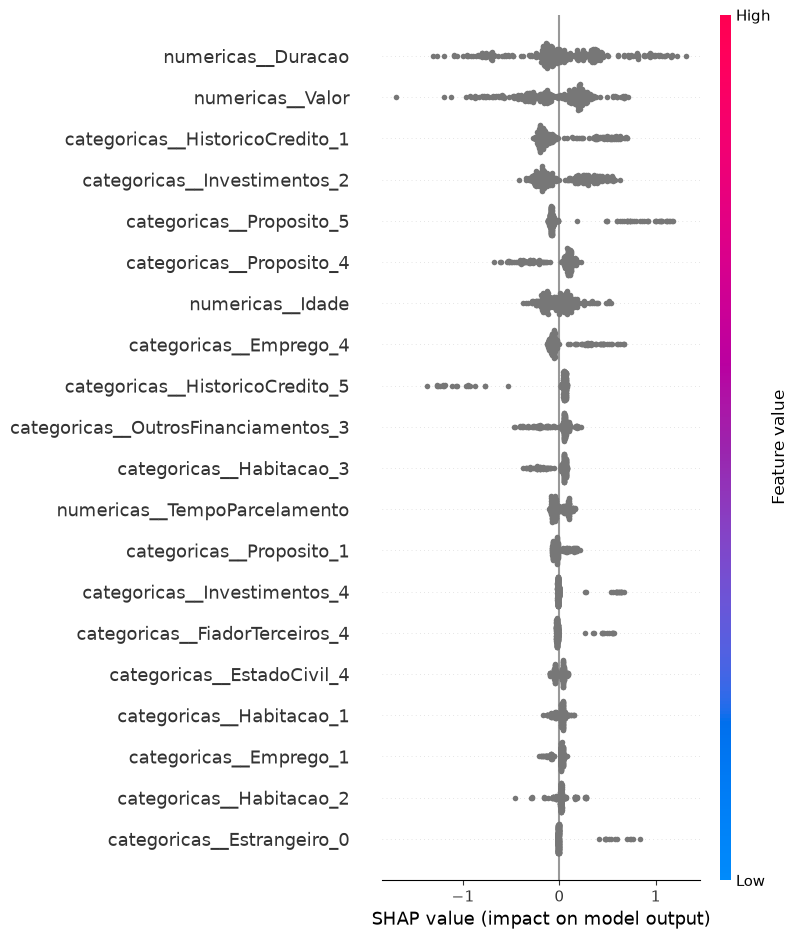

In [ ]:
# Gerar o gráfico de resumo SHAP
shap.summary_plot(
    shap_values,
    X_test_transformado,
    feature_names=feature_names
)

# IMPORTANCIA DAS VARIAVEIS ( SEM GRAFICO )

In [ ]:
import pandas as pd
import numpy as np

importancia = pd.DataFrame({
    "Variavel": feature_names,
    "Importancia": np.abs(shap_values).mean(axis=0)
})

importancia = importancia.sort_values(
    "Importancia",
    ascending=False
)

print(importancia.head(10))

                               Variavel  Importancia
0                    numericas__Duracao     0.383855
1                      numericas__Valor     0.296801
6       categoricas__HistoricoCredito_1     0.239381
22         categoricas__Investimentos_2     0.234943
15             categoricas__Proposito_5     0.182212
14             categoricas__Proposito_4     0.157543
2                      numericas__Idade     0.123137
29               categoricas__Emprego_4     0.122224
10      categoricas__HistoricoCredito_5     0.119765
47  categoricas__OutrosFinanciamentos_3     0.100203


# GRAFICO DAS 10 VARIAVEIS MAIS IMPORTANTES

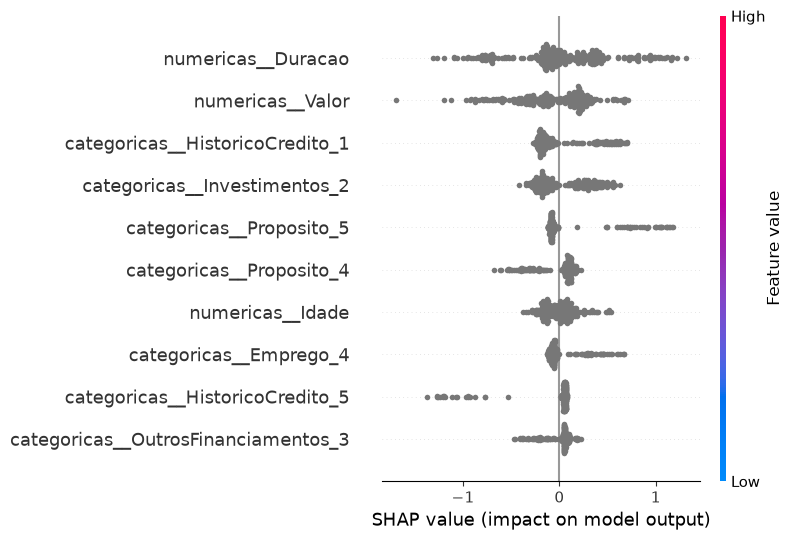

In [ ]:
# Gerar o gráfico de resumo SHAP com as 10 variáveis mais importantes
shap.summary_plot(
    shap_values,
    X_test_transformado,
    feature_names=feature_names,
    max_display=10
)

In [ ]:
print(importancia.head(10))

                               Variavel  Importancia
0                    numericas__Duracao     0.383855
1                      numericas__Valor     0.296801
6       categoricas__HistoricoCredito_1     0.239381
22         categoricas__Investimentos_2     0.234943
15             categoricas__Proposito_5     0.182212
14             categoricas__Proposito_4     0.157543
2                      numericas__Idade     0.123137
29               categoricas__Emprego_4     0.122224
10      categoricas__HistoricoCredito_5     0.119765
47  categoricas__OutrosFinanciamentos_3     0.100203


# 11. Conclusão Técnica

O projeto desenvolveu um modelo de Machine Learning para previsão de risco de crédito utilizando uma base histórica contendo informações financeiras e características dos clientes.

Durante o desenvolvimento foram avaliados diferentes algoritmos de classificação, incluindo Logistic Regression e XGBoost.

O modelo XGBoost apresentou o melhor desempenho entre os modelos testados, alcançando:

- Acurácia aproximada: 77%
- Recall da classe inadimplente: 41%
- F1-score da classe inadimplente: 52%

Além da avaliação utilizando o threshold padrão de 0.5, foram realizados testes com diferentes pontos de corte para analisar o impacto entre identificar mais clientes de risco e reduzir falsos positivos.

Em problemas de crédito, o recall possui grande importância, pois representa a capacidade do modelo de identificar clientes com maior probabilidade de inadimplência.

A análise de importância das variáveis indicou que os principais fatores utilizados pelo modelo foram:

- Duração do crédito;
- Valor solicitado;
- Histórico de crédito;
- Investimentos;
- Propósito do empréstimo;
- Idade;
- Categoria de emprego.

Esses resultados demonstram que o modelo consegue capturar padrões relevantes relacionados ao comportamento de crédito dos clientes.

Como próxima etapa para um ambiente produtivo, seria recomendado realizar calibração do modelo, monitoramento de performance e integração com ferramentas de Business Intelligence para acompanhamento dos indicadores de risco.